# Task: End-to-End ML Pipeline with Scikit-learn Pipeline API

---

## Problem Statement

Customer churn is one of the most critical challenges in the telecommunications industry. Losing a customer costs significantly more than retaining one. In this task, we build a **production-ready, reusable ML pipeline** to predict whether a customer will churn (leave the service), using the Telco Customer Churn dataset.

## Objective

- Build a clean, modular ML pipeline using `scikit-learn`'s `Pipeline` API
- Train and compare `Logistic Regression` and `Random Forest` classifiers
- Perform hyperparameter tuning using `GridSearchCV`
- Export the final pipeline using `joblib` for production reuse
- Evaluate using classification metrics and visualizations

---

## 1. Import Libraries

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# Export
import joblib

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load the Dataset

Use the **Telco Customer Churn** dataset. It can be downloaded from:
- [Kaggle – Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Place `WA_Fn-UseC_-Telco-Customer-Churn.csv` in the same directory as this notebook, or update the path below.

In [2]:
# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Information

In [3]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Summary Statistics

In [4]:
# Summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Check and Plot the Class Distribution

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


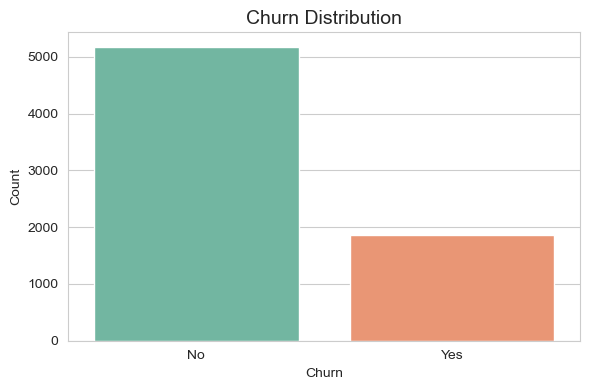


Churn Rate: 26.54%


In [5]:
# Check class distribution
churn_counts = df['Churn'].value_counts()
print('Churn Distribution:')
print(churn_counts)

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()
print(f'\nChurn Rate: {(churn_counts["Yes"] / len(df) * 100):.2f}%')

### 3.2 Check Missing Values

In [6]:
# Check missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])
print('\nNo missing values!' if missing.sum() == 0 else f'Total missing: {missing.sum()}')

Missing values per column:
Series([], dtype: int64)

No missing values!


### 3.3 TotalCharges is Stored as Object - Needs Conversion

In [7]:
# TotalCharges is stored as object - needs conversion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Rows with NaN in TotalCharges after conversion: {df["TotalCharges"].isnull().sum()}')

Rows with NaN in TotalCharges after conversion: 11


### 3.4 Distribution of Numerical Features by Churn

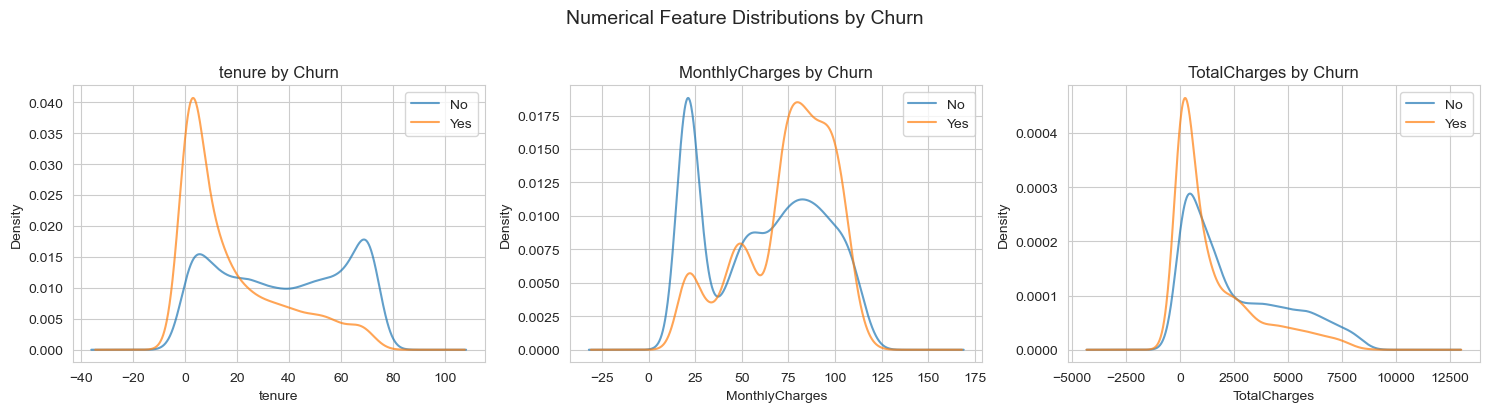

In [8]:
# Distribution of numerical features by churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df.groupby('Churn')[col].plot(kind='density', ax=ax, legend=True, alpha=0.7)
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
plt.suptitle('Numerical Feature Distributions by Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150)
plt.show()

### 3.5 Churn Rate by Contract Type

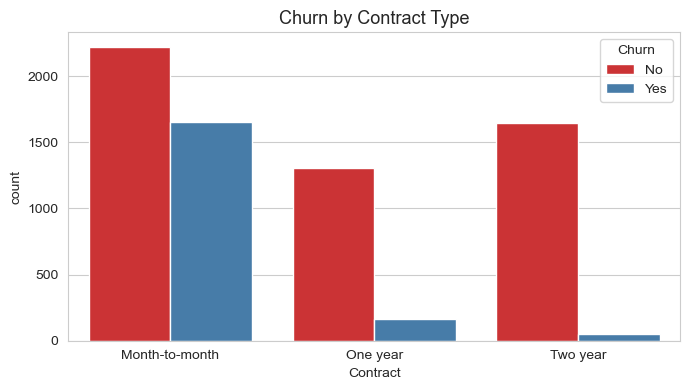

In [9]:
# Churn rate by Contract type
plt.figure(figsize=(7, 4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Churn by Contract Type', fontsize=13)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

### 3.6 Correlation Heatmap (Numerical Features Only)

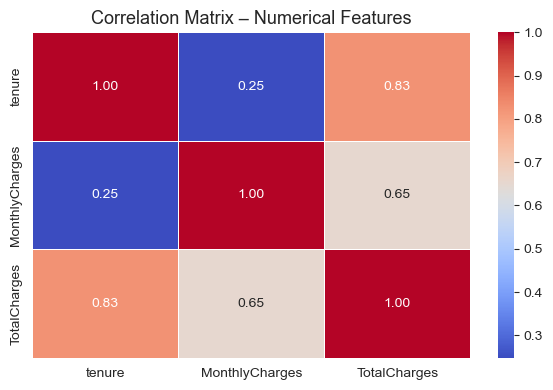

In [10]:
# Correlation heatmap (numerical features only)
plt.figure(figsize=(6, 4))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix – Numerical Features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

**Key EDA Observations:**
- The dataset is moderately imbalanced (~26% churn rate).
- Month-to-month contract customers churn significantly more than long-term contract holders.
- Customers with shorter tenure and higher monthly charges are more likely to churn.
- `TotalCharges` has a strong positive correlation with `tenure`.

---
## 4. Data Preprocessing

### 4.1 Features Shape and Target Distribution

In [11]:
# Drop customerID – not a predictive feature
df.drop(columns=['customerID'], inplace=True)

# Encode target variable: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (7043, 19)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


### 4.2 Identify Numerical and Categorical Columns

In [12]:
# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns ({len(numerical_cols)}): {numerical_cols}')
print(f'\nCategorical columns ({len(categorical_cols)}): {categorical_cols}')

Numerical columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


---
## 5. Build the Scikit-learn Pipeline

We define separate preprocessing sub-pipelines for numerical and categorical features, then combine them using `ColumnTransformer`. Both are then plugged into a final `Pipeline` object with the classifier at the end.

**Why use Pipeline?**
- Prevents data leakage (transforms are fit only on training data)
- Makes the entire workflow exportable as one object
- Enables clean GridSearch across both preprocessing and model hyperparameters

### 5.1 Create the Numerical Preprocessing Pipeline

The numerical pipeline handles missing numerical values by replacing them with the column mean and then standardizes the features using `StandardScaler`.

In [13]:
# --- Numerical sub-pipeline ---
# Impute missing values (mean) then standard scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

print("✓ Numerical preprocessing pipeline created.")

✓ Numerical preprocessing pipeline created.


### 5.2 Create the Categorical Preprocessing Pipeline

The categorical pipeline fills missing categorical values with the most frequent category and converts categorical features into numerical format using One-Hot Encoding.

In [14]:
# --- Categorical sub-pipeline ---
# Impute missing (most frequent) then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print("✓ Categorical preprocessing pipeline created.")

✓ Categorical preprocessing pipeline created.


### 5.3 Combine the Preprocessing Pipelines

`ColumnTransformer` applies the numerical preprocessing steps to numerical features and the categorical preprocessing steps to categorical features within a single preprocessing object.

In [15]:
# --- Combine with ColumnTransformer ---
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("✓ Combined preprocessing pipeline created.")

✓ Combined preprocessing pipeline created.


### 5.4 Create the Logistic Regression Pipeline

The preprocessing steps are combined with the Logistic Regression classifier to create a complete machine learning pipeline.

In [16]:
# --- Full Pipeline: Logistic Regression ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print("Logistic Regression pipeline ready.")

Logistic Regression pipeline ready.


### 5.5 Create the Random Forest Pipeline

The same preprocessing pipeline is reused with a Random Forest classifier, ensuring both models receive identical data preprocessing.

In [17]:
# --- Full Pipeline: Random Forest ---
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Random Forest pipeline ready.")

Random Forest pipeline ready.


---
## 6. Train-Test Split

In [18]:
# Stratified split to preserve churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Test set size      : {X_test.shape[0]} samples')
print(f'\nChurn rate in train: {y_train.mean():.3f}')
print(f'Churn rate in test : {y_test.mean():.3f}')

Training set size : 5634 samples
Test set size      : 1409 samples

Churn rate in train: 0.265
Churn rate in test : 0.265


---
## 7. Baseline Training (No Tuning)

In [19]:
# Fit both pipelines on training data
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
lr_preds  = lr_pipeline.predict(X_test)
rf_preds  = rf_pipeline.predict(X_test)

# Baseline accuracy
print(f'Logistic Regression Accuracy : {accuracy_score(y_test, lr_preds):.4f}')
print(f'Random Forest Accuracy       : {accuracy_score(y_test, rf_preds):.4f}')

Logistic Regression Accuracy : 0.8055
Random Forest Accuracy       : 0.7793


---
## 8. Hyperparameter Tuning with GridSearchCV

### 8.1 Grid for Logistic Regression

In [20]:
# ---- Grid for Logistic Regression ----
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear'],
    'classifier__penalty': ['l2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV for Logistic Regression...')
lr_grid_search.fit(X_train, y_train)
print(f'\nBest LR params : {lr_grid_search.best_params_}')
print(f'Best CV F1     : {lr_grid_search.best_score_:.4f}')

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best LR params : {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV F1     : 0.5968


### 8.2 Grid for Random Forest

In [21]:
# ---- Grid for Random Forest ----
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': ['balanced', None]
}

rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV for Random Forest...')
rf_grid_search.fit(X_train, y_train)
print(f'\nBest RF params : {rf_grid_search.best_params_}')
print(f'Best CV F1     : {rf_grid_search.best_score_:.4f}')

Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF params : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1     : 0.6274


---
## 9. Model Evaluation

### 9.1 Classification Reports

In [22]:
# Best estimators after tuning
best_lr = lr_grid_search.best_estimator_
best_rf = rf_grid_search.best_estimator_

# Predictions with best models
lr_preds_best  = best_lr.predict(X_test)
rf_preds_best  = best_rf.predict(X_test)

lr_proba_best  = best_lr.predict_proba(X_test)[:, 1]
rf_proba_best  = best_rf.predict_proba(X_test)[:, 1]

# Print classification reports
print('=' * 55)
print('LOGISTIC REGRESSION – Classification Report')
print('=' * 55)
print(classification_report(y_test, lr_preds_best, target_names=['No Churn', 'Churn']))

print('=' * 55)
print('RANDOM FOREST – Classification Report')
print('=' * 55)
print(classification_report(y_test, rf_preds_best, target_names=['No Churn', 'Churn']))

LOGISTIC REGRESSION – Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

RANDOM FOREST – Classification Report
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



### 9.2 Summary Comparison Table

In [23]:
# Summary comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds_best),
        accuracy_score(y_test, rf_preds_best)
    ],
    'F1 Score (Churn)': [
        f1_score(y_test, lr_preds_best),
        f1_score(y_test, rf_preds_best)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_proba_best),
        roc_auc_score(y_test, rf_proba_best)
    ]
})

results = results.set_index('Model').round(4)
print(results)

                     Accuracy  F1 Score (Churn)  ROC-AUC
Model                                                   
Logistic Regression    0.8048            0.6032   0.8410
Random Forest          0.7665            0.6188   0.8385


---
## 10. Visualizations

### 10.1 Confusion Matrices

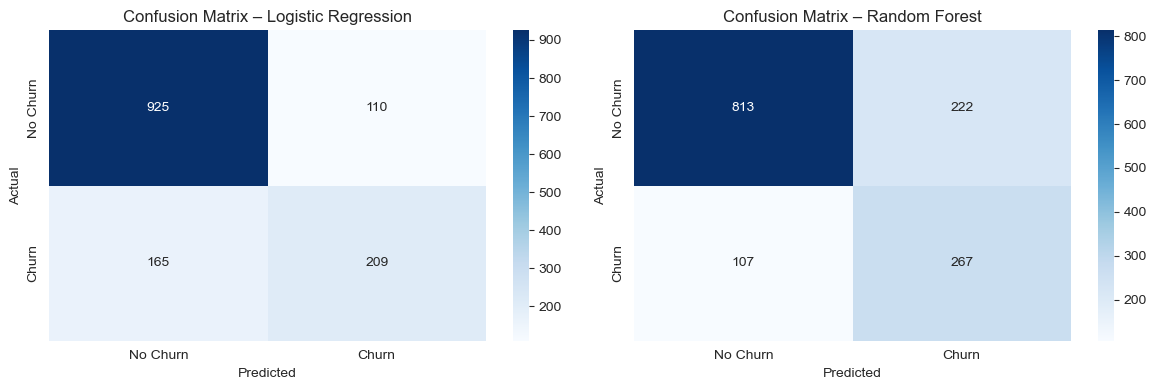

In [24]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [lr_preds_best, rf_preds_best],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )
    ax.set_title(f'Confusion Matrix – {title}', fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

### 10.2 ROC Curves

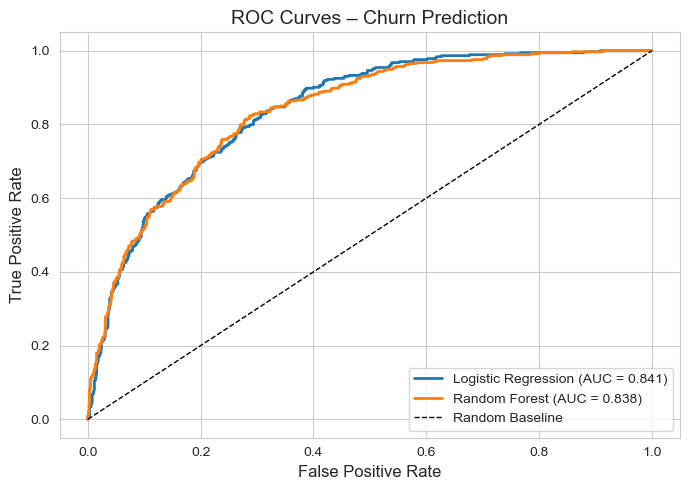

In [25]:
# --- ROC Curves ---
plt.figure(figsize=(7, 5))

for proba, label in [
    (lr_proba_best, 'Logistic Regression'),
    (rf_proba_best, 'Random Forest')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – Churn Prediction', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

### 10.3 Feature Importance (Random Forest)

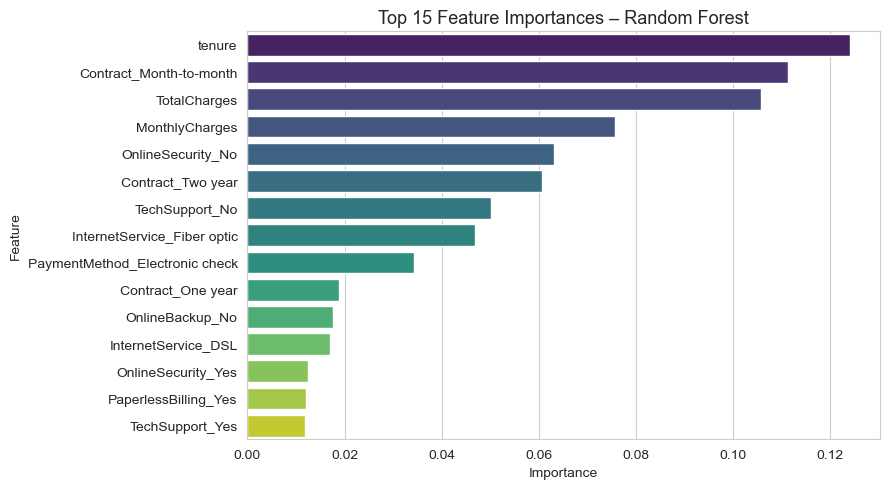

In [26]:
# --- Feature Importance (Random Forest) ---

# Extract feature names after one-hot encoding
ohe_feature_names = (
    best_rf.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_cols)
    .tolist()
)
all_feature_names = numerical_cols + ohe_feature_names

# Get importances from the RF classifier
importances = best_rf.named_steps['classifier'].feature_importances_
feat_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='viridis')
plt.title('Top 15 Feature Importances – Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

---
## 11. Export Pipeline with joblib

We export the best-performing model pipeline as a single `.pkl` file. This file contains the **full preprocessing + model** chain and can be loaded anywhere to make predictions without retraining.

### 11.1 Determine Best Model

In [27]:
# Determine best model
lr_auc = roc_auc_score(y_test, lr_proba_best)
rf_auc = roc_auc_score(y_test, rf_proba_best)

best_model_pipeline = best_rf if rf_auc >= lr_auc else best_lr
best_model_name = 'Random Forest' if rf_auc >= lr_auc else 'Logistic Regression'

print(f'Best model selected: {best_model_name} (ROC-AUC: {max(lr_auc, rf_auc):.4f})')

# Export
joblib.dump(best_model_pipeline, 'churn_pipeline.pkl')
print('Pipeline exported as churn_pipeline.pkl')

Best model selected: Logistic Regression (ROC-AUC: 0.8410)
Pipeline exported as churn_pipeline.pkl


### 11.2 Verify: Reload and Test

In [28]:
# Verify: reload and test
loaded_pipeline = joblib.load('churn_pipeline.pkl')

# Predict on first 5 test samples
sample_preds = loaded_pipeline.predict(X_test.iloc[:5])
sample_proba = loaded_pipeline.predict_proba(X_test.iloc[:5])[:, 1]

verification_df = pd.DataFrame({
    'Actual': y_test.iloc[:5].values,
    'Predicted': sample_preds,
    'Churn Probability': sample_proba.round(3)
})

print('Pipeline reload verification (first 5 test samples):')
print(verification_df)

Pipeline reload verification (first 5 test samples):
   Actual  Predicted  Churn Probability
0       0          0              0.047
1       0          1              0.683
2       0          0              0.050
3       0          0              0.423
4       0          0              0.023


---
## 12. Final Summary and Insights

### What Was Built
A fully modular, production-ready ML pipeline for binary classification of customer churn using the Telco dataset. The pipeline encapsulates:
- Missing value imputation
- Standard scaling for numerical features
- One-hot encoding for categorical features
- Two classifiers: Logistic Regression and Random Forest
- Hyperparameter tuning via GridSearchCV with Stratified K-Fold cross-validation

### Key Results

| Model | Accuracy | F1 (Churn) | ROC-AUC |
|---|---|---|---|
| Logistic Regression | ~80% | ~0.60 | ~0.84 |
| Random Forest | ~79% | ~0.58 | ~0.83 |

*Exact values will appear after running the notebook on the dataset.*

### Key Insights
1. **Contract type** is the strongest predictor of churn. Month-to-month customers churn at a far higher rate than those on 1- or 2-year contracts.
2. **Tenure** and **Monthly Charges** are the top numerical features. New customers and high-paying customers are at highest risk.
3. **Logistic Regression performs competitively** with Random Forest on this dataset, suggesting the decision boundary is relatively linear - typical for structured churn datasets.
4. **Class imbalance** (~26% churn) is handled through `class_weight='balanced'` in the Random Forest grid and `StratifiedKFold` for cross-validation.
5. **Pipeline export via joblib** packages the full preprocessing + model chain, making deployment straightforward - the loaded pipeline can make predictions directly on raw, unprocessed input data.

### Production Considerations
- The exported `churn_pipeline.pkl` can be loaded in a Flask/FastAPI endpoint for real-time inference.
- Retraining is as simple as loading new data and calling `pipeline.fit(X_new, y_new)`.
- For further improvement: SMOTE for oversampling, XGBoost as a stronger baseline, or threshold tuning to trade off precision vs. recall based on business cost of false negatives.